# DNN v2 — Melhorado

Melhorias em relação ao DNN original:
- **FFNNv2**: BatchNorm, skip-connections, activação GELU
- **Features estilométricas**: 18 features numéricas que capturam estilo de escrita (TTR, pontuação, comprimentos, etc.)
- **CombinedVectorizerV2**: TF-IDF palavras + char n-grams + estilometria
- **Label Smoothing** na loss
- **Learning Rate Scheduler** (ReduceLROnPlateau)
- **Dados revelados da Subm1** integrados no treino
- **Optuna** para otimização de hiperparâmetros

In [9]:
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report
import optuna

from text_features import CombinedVectorizerV2, encode_labels, decode_labels
from ffnn import FFNNv2, evaluate_loss_accuracy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

N_CLASSES = 5

device: cpu


## *dados*

Carrega dataset v2 + dados revelados da Subm1 para aumentar o treino.

In [21]:
df_train = pd.read_csv('../datasets/dataset_v2_train.csv', sep=';')
df_test  = pd.read_csv('../datasets/dataset_v2_test.csv',  sep=';')
df_val   = pd.read_csv('../datasets/dataset_v2_val.csv',   sep=';')

# integrar dados revelados da Subm1 no treino
df_subm1 = pd.read_csv('../Subm1/subm1_labels_revealed.csv', sep=';')

# normalizar labels (Subm1 tem "OpenAI" vs treino "Openai", etc.)
LABEL_MAP = {'google': 'Google', 'anthropic': 'Anthropic', 'meta': 'Meta',
             'openai': 'Openai', 'human': 'Human'}
df_subm1['Label'] = df_subm1['Label'].str.lower().map(LABEL_MAP)

df_train_aug = pd.concat([df_train, df_subm1], ignore_index=True)

print(f'treino original: {len(df_train)} | + subm1: {len(df_subm1)} | total: {len(df_train_aug)}')
print(f'teste: {len(df_test)} | val: {len(df_val)}')
print('\ndistribuição de treino aumentado:')
print(df_train_aug['Label'].value_counts())

treino original: 3500 | + subm1: 100 | total: 3600
teste: 750 | val: 750

distribuição de treino aumentado:
Label
Human        734
Meta         718
Anthropic    717
Google       717
Openai       714
Name: count, dtype: int64


## *features*

CombinedVectorizerV2: TF-IDF palavras (1,2)-grams + char (3,5)-grams + 18 features estilométricas.

In [11]:
train_texts = df_train_aug['Text'].fillna('').tolist()
test_texts  = df_test['Text'].fillna('').tolist()
val_texts   = df_val['Text'].fillna('').tolist()

vec = CombinedVectorizerV2(
    max_words=15000, ngram_range=(1, 2),
    max_chars=10000,  char_range=(3, 5)
)

X_train = vec.fit_transform(train_texts)
X_test  = vec.transform(test_texts)
X_val   = vec.transform(val_texts)

Y_train = encode_labels(df_train_aug['Label'].tolist())
Y_test  = encode_labels(df_test['Label'].tolist())
Y_val   = encode_labels(df_val['Label'].tolist())

print(f'dimensão das features: {X_train.shape[1]}')
print(f'  - TF-IDF palavras: {vec.tfidf.max_words}')
print(f'  - char n-grams:    {vec.char_vec.max_features}')
print(f'  - estilométricas:  18')

dimensão das features: 25018
  - TF-IDF palavras: 15000
  - char n-grams:    10000
  - estilométricas:  18


In [12]:
def make_loader(X, y, batch_size=64, shuffle=False):
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(Xt, yt), batch_size=batch_size, shuffle=shuffle)

train_loader = make_loader(X_train, Y_train, batch_size=64, shuffle=True)
test_loader  = make_loader(X_test,  Y_test,  batch_size=64)
val_loader   = make_loader(X_val,   Y_val,   batch_size=64)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape} | X_val: {X_val.shape}')

X_train: (3600, 25018) | X_test: (750, 25018) | X_val: (750, 25018)


## *optuna — otimização de hiperparâmetros*

Procura a melhor combinação de topologia, dropout, lr, weight_decay, activação e label_smoothing.

In [13]:
def train_and_evaluate(model, train_loader, val_loader, criterion, optimizer, scheduler,
                       num_epochs=150, patience=20):
    """Treina o modelo e retorna a melhor val_acc e o state_dict correspondente."""
    best_val_acc = 0.0
    best_state = None
    no_improve = 0

    for epoch in range(1, num_epochs + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        val_loss, val_acc = evaluate_loss_accuracy(model, val_loader, criterion)
        scheduler.step(val_loss)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break

    return best_val_acc, best_state

In [14]:
def objective(trial):
    # hiperparâmetros a otimizar
    n_layers   = trial.suggest_int('n_layers', 2, 4)
    topology   = [trial.suggest_categorical(f'dim_{i}', [128, 256, 512, 768]) for i in range(n_layers)]
    dropout    = trial.suggest_float('dropout', 0.2, 0.5)
    lr         = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    wd         = trial.suggest_float('weight_decay', 1e-5, 1e-2, log=True)
    smoothing  = trial.suggest_float('label_smoothing', 0.0, 0.15)
    activation = trial.suggest_categorical('activation', ['gelu', 'silu', 'relu', 'leakyrelu'])

    model = FFNNv2(
        input_dim=X_train.shape[1], n_classes=N_CLASSES,
        topology=topology, dropout=dropout, activation=activation
    ).to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=smoothing)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=7, factor=0.5)

    best_val_acc, _ = train_and_evaluate(model, train_loader, val_loader, criterion,
                                         optimizer, scheduler, num_epochs=120, patience=18)
    return best_val_acc


study = optuna.create_study(direction='maximize', study_name='dnn_v2')
study.optimize(objective, n_trials=40, show_progress_bar=True)

print(f'\nmelhor val_acc: {study.best_value:.4f}')
print('melhores hiperparâmetros:')
for k, v in study.best_params.items():
    print(f'  {k}: {v}')

[I 2026-03-30 03:16:00,399] A new study created in memory with name: dnn_v2


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-03-30 03:16:21,836] Trial 0 finished with value: 0.9986666666666667 and parameters: {'n_layers': 3, 'dim_0': 128, 'dim_1': 128, 'dim_2': 256, 'dropout': 0.4300243300899402, 'lr': 0.003005092974626477, 'weight_decay': 0.00012930421231802696, 'label_smoothing': 0.10252289730697155, 'activation': 'relu'}. Best is trial 0 with value: 0.9986666666666667.
[I 2026-03-30 03:17:34,808] Trial 1 finished with value: 0.9986666666666667 and parameters: {'n_layers': 4, 'dim_0': 512, 'dim_1': 256, 'dim_2': 768, 'dim_3': 768, 'dropout': 0.30446840888342, 'lr': 0.003923364931749861, 'weight_decay': 1.2822970907745765e-05, 'label_smoothing': 0.14591141795314344, 'activation': 'silu'}. Best is trial 0 with value: 0.9986666666666667.
[I 2026-03-30 03:19:06,943] Trial 2 finished with value: 0.9986666666666667 and parameters: {'n_layers': 3, 'dim_0': 768, 'dim_1': 128, 'dim_2': 512, 'dropout': 0.2363503491466012, 'lr': 0.0036493257220370904, 'weight_decay': 0.00035439764628123925, 'label_smoothing':

## *treino final com melhores hiperparâmetros*

In [15]:
bp = study.best_params
topology = [bp[f'dim_{i}'] for i in range(bp['n_layers'])]

print(f'Topologia: {topology}')
print(f'Dropout: {bp["dropout"]:.3f} | LR: {bp["lr"]:.5f} | WD: {bp["weight_decay"]:.5f}')
print(f'Label Smoothing: {bp["label_smoothing"]:.3f} | Activação: {bp["activation"]}')

Topologia: [128, 128, 256]
Dropout: 0.430 | LR: 0.00301 | WD: 0.00013
Label Smoothing: 0.103 | Activação: relu


In [16]:
model = FFNNv2(
    input_dim=X_train.shape[1], n_classes=N_CLASSES,
    topology=topology, dropout=bp['dropout'], activation=bp['activation']
).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=bp['label_smoothing'])
optimizer = torch.optim.AdamW(model.parameters(), lr=bp['lr'], weight_decay=bp['weight_decay'])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=7, factor=0.5)

NUM_EPOCHS = 200
PATIENCE   = 25

best_val_acc = 0.0
best_state   = None
no_improve   = 0

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    running_loss    = 0.0
    running_correct = 0
    running_total   = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        running_loss    += loss.item() * xb.size(0)
        preds            = logits.argmax(dim=1)
        running_correct += (preds == yb).sum().item()
        running_total   += yb.size(0)

    train_loss = running_loss / running_total
    train_acc  = running_correct / running_total
    val_loss, val_acc = evaluate_loss_accuracy(model, val_loader, criterion)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    if epoch % 10 == 0:
        current_lr = optimizer.param_groups[0]['lr']
        print(f'Epoch {epoch:03d}/{NUM_EPOCHS} | train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f} | lr={current_lr:.6f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state   = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve   = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f'early stopping na epoch {epoch}')
            break

model.load_state_dict(best_state)
print(f'\nmelhor modelo -> val_acc={best_val_acc:.4f}')

Epoch 010/200 | train_loss=0.4148 | train_acc=0.9997 | val_loss=0.4077 | val_acc=0.9987 | lr=0.003005
Epoch 020/200 | train_loss=0.4115 | train_acc=1.0000 | val_loss=0.4073 | val_acc=0.9987 | lr=0.003005
early stopping na epoch 27

melhor modelo -> val_acc=0.9987


## *curvas de treino*

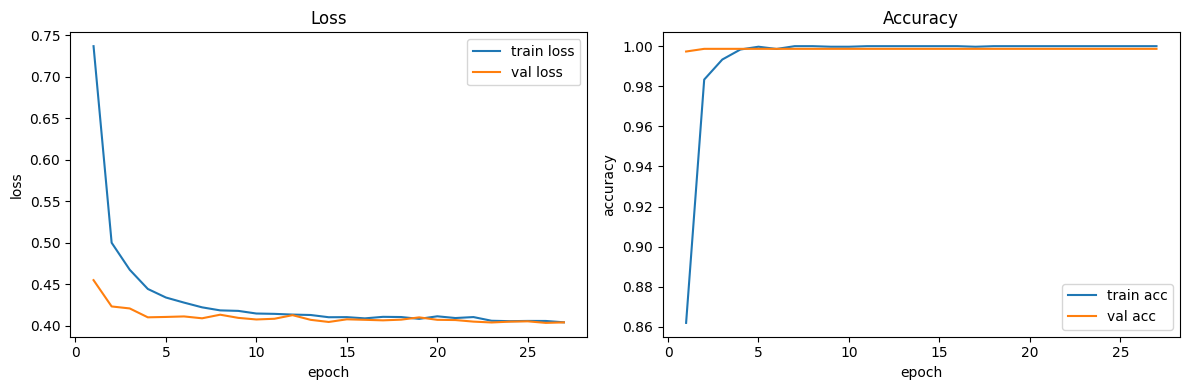

[TRAIN] accuracy=0.9992
[TEST]  accuracy=1.0000
[VAL]   accuracy=0.9987


In [17]:
epochs_range = range(1, len(train_losses) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs_range, train_losses, label='train loss')
axes[0].plot(epochs_range, val_losses,   label='val loss')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(epochs_range, train_accs, label='train acc')
axes[1].plot(epochs_range, val_accs,   label='val acc')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].set_title('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

_, train_acc = evaluate_loss_accuracy(model, train_loader, criterion)
_, test_acc  = evaluate_loss_accuracy(model, test_loader,  criterion)
_, val_acc   = evaluate_loss_accuracy(model, val_loader,   criterion)
print(f'[TRAIN] accuracy={train_acc:.4f}')
print(f'[TEST]  accuracy={test_acc:.4f}')
print(f'[VAL]   accuracy={val_acc:.4f}')

## *guardar modelo e vectorizer*

In [18]:
torch.save(model.state_dict(), '../models/model_dnn_v2.pt')
with open('../vectorizers/vectorizer_dnn_v2.pkl', 'wb') as f:
    pickle.dump(vec, f)

# guardar também os best_params para referência
with open('../models/dnn_v2_best_params.pkl', 'wb') as f:
    pickle.dump(study.best_params, f)

print('modelo, vectorizer e hiperparâmetros guardados.')

modelo, vectorizer e hiperparâmetros guardados.


## *avaliação com dataset-exemplos*

In [19]:
df_ex = pd.read_csv('../datasets/dataset-exemplos.csv', sep=';')
X_ex  = vec.transform(df_ex['Text'].fillna('').tolist())
Y_ex  = encode_labels(df_ex['Label'].tolist())
ex_loader = make_loader(X_ex, Y_ex, batch_size=64)

model.eval()
preds_all = []
with torch.no_grad():
    for xb, _ in ex_loader:
        logits = model(xb.to(device))
        preds_all.extend(logits.argmax(dim=1).cpu().tolist())

preds_decoded = decode_labels(preds_all)
print(classification_report(
    df_ex['Label'].str.lower().tolist(),
    preds_decoded,
    digits=3
))

              precision    recall  f1-score   support

   anthropic      0.750     0.522     0.615        23
      google      1.000     0.250     0.400        16
       human      0.536     1.000     0.698        52
        meta      0.600     0.176     0.273        17
      openai      0.667     0.118     0.200        17

    accuracy                          0.584       125
   macro avg      0.711     0.413     0.437       125
weighted avg      0.661     0.584     0.519       125



## *avaliação com Subm1 (dados agora no treino)*

**Nota:** como os dados da Subm1 foram usados no treino, esta avaliação serve apenas para verificar que o modelo os aprendeu. A avaliação real é no dataset-exemplos e no test set.

In [20]:
X_subm1      = vec.transform(df_subm1['Text'].fillna('').tolist())
Y_subm1      = encode_labels(df_subm1['Label'].tolist())
subm1_loader = make_loader(X_subm1, Y_subm1, batch_size=64)

model.eval()
preds_all = []
with torch.no_grad():
    for xb, _ in subm1_loader:
        logits = model(xb.to(device))
        preds_all.extend(logits.argmax(dim=1).cpu().tolist())

preds_decoded = decode_labels(preds_all)
print(classification_report(
    df_subm1['Label'].str.lower().tolist(),
    preds_decoded,
    digits=3
))

              precision    recall  f1-score   support

   anthropic      1.000     1.000     1.000        17
      google      1.000     0.882     0.938        17
       human      1.000     1.000     1.000        34
        meta      0.900     1.000     0.947        18
      openai      0.929     0.929     0.929        14

    accuracy                          0.970       100
   macro avg      0.966     0.962     0.963       100
weighted avg      0.972     0.970     0.970       100

